In [1]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
my_df = pd.read_excel("oficial.xlsx", sheet_name="Codificada")

In [3]:
x = my_df.drop(
    ["Paciente_ID", "Risco de Ataque Cardíaco"],
    axis=1
)

y = my_df["Risco de Ataque Cardíaco"]

In [4]:
x_train, x_temp, y_train, y_temp = train_test_split(
    x,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [5]:
x_val, x_test, y_val, y_test = train_test_split(
    x_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [6]:
print(y_train.value_counts())

Risco de Ataque Cardíaco
0    1195
1     661
Name: count, dtype: int64


In [7]:
smote = SMOTE(random_state=42)

x_train_bal, y_train_bal = smote.fit_resample(
    x_train,
    y_train
)

In [8]:
print(y_train_bal.value_counts())

Risco de Ataque Cardíaco
0    1195
1    1195
Name: count, dtype: int64


In [9]:
print(x_train.shape)

print(x_train_bal.shape)

(1856, 21)
(2390, 21)


In [10]:
# Confirma que os dados não foram normalizados
print("Média x_train_bal (esperado: valores originais, não ~0):")
print(x_train_bal.mean().head())

print("\nMédia x_test:")
print(x_test.mean().head())

Média x_train_bal (esperado: valores originais, não ~0):
Idade                    53.863598
Colesterol              261.151464
Pressão Sistólica       135.310879
Pressão Diastólica       84.796234
Batimentos Cardíacos     74.858996
dtype: float64

Média x_test:
Idade                    52.577889
Colesterol              259.128141
Pressão Sistólica       134.881910
Pressão Diastólica       85.731156
Batimentos Cardíacos     76.457286
dtype: float64



RESULTADOS - RANDOM FOREST

Accuracy: 0.5578

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.70      0.67       257
           1       0.35      0.29      0.32       141

    accuracy                           0.56       398
   macro avg       0.50      0.50      0.50       398
weighted avg       0.54      0.56      0.55       398


Matriz de Confusão:
[[181  76]
 [100  41]]


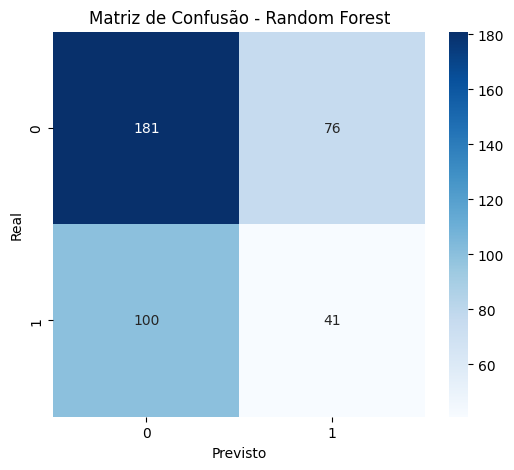

In [11]:
# =========================================================
# RANDOM FOREST
# =========================================================


# =========================================================
# CRIAÇÃO DO MODELO
# =========================================================
# n_estimators -> número de árvores na floresta
# max_depth    -> profundidade máxima de cada árvore
# random_state -> semente para reprodutibilidade

model = RandomForestClassifier(

    n_estimators=100,
    max_depth=10,
    random_state=42

)

# =========================================================
# TREINAMENTO
# =========================================================
# Random Forest NÃO precisa de normalização (StandardScaler)
# pois é baseado em árvores de decisão

model.fit(x_train_bal, y_train_bal)

# =========================================================
# PREDIÇÕES
# =========================================================

y_pred = model.predict(x_test)

# =========================================================
# AVALIAÇÃO DO MODELO
# =========================================================

accuracy = accuracy_score(y_test, y_pred)

print("\n===================================")
print("RESULTADOS - RANDOM FOREST")
print("===================================")

print(f"\nAccuracy: {accuracy:.4f}")

# =========================================================
# RELATÓRIO DE CLASSIFICAÇÃO
# =========================================================

print("\nClassification Report:")

print(classification_report(y_test, y_pred))

# =========================================================
# MATRIZ DE CONFUSÃO
# =========================================================

cm = confusion_matrix(y_test, y_pred)

print("\nMatriz de Confusão:")
print(cm)

# =========================================================
# VISUALIZAÇÃO DA MATRIZ
# =========================================================

plt.figure(figsize=(6, 5))

sns.heatmap(

    cm,

    annot=True,
    fmt='d',
    cmap='Blues'

)

plt.title('Matriz de Confusão - Random Forest')

plt.xlabel('Previsto')
plt.ylabel('Real')

plt.show()

C:\Users\kirst\AppData\Local\Temp\ipykernel_12168\3222888392.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


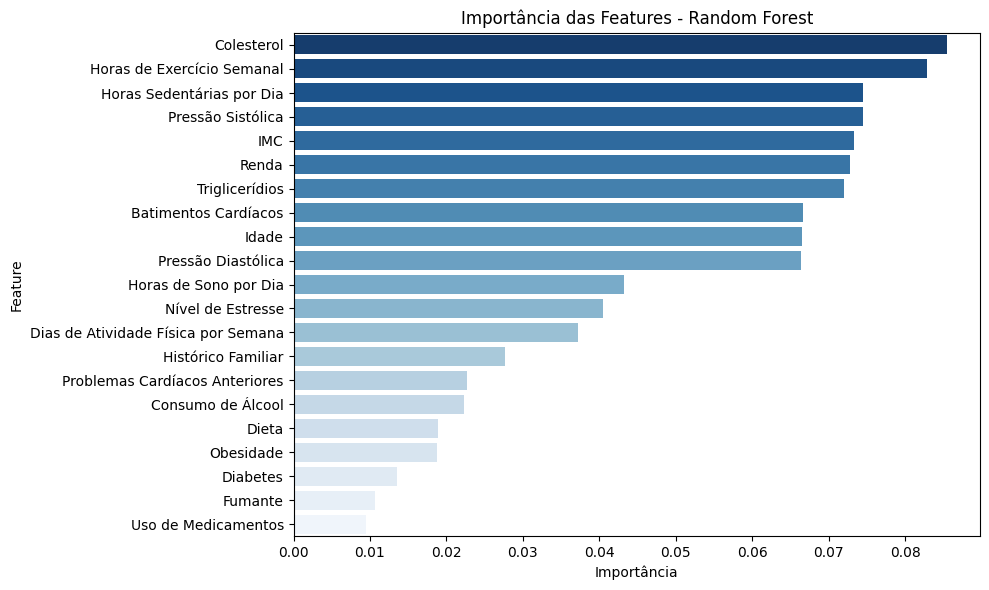


Ranking de importância:
Colesterol                             0.085520
Horas de Exercício Semanal             0.082847
Horas Sedentárias por Dia              0.074509
Pressão Sistólica                      0.074451
IMC                                    0.073359
Renda                                  0.072834
Triglicerídios                         0.071989
Batimentos Cardíacos                   0.066697
Idade                                  0.066570
Pressão Diastólica                     0.066363
Horas de Sono por Dia                  0.043173
Nível de Estresse                      0.040544
Dias de Atividade Física por Semana    0.037207
Histórico Familiar                     0.027694
Problemas Cardíacos Anteriores         0.022632
Consumo de Álcool                      0.022314
Dieta                                  0.018925
Obesidade                              0.018718
Diabetes                               0.013514
Fumante                                0.010638
Uso de Medicame

In [12]:
# =========================================================
# IMPORTÂNCIA DAS FEATURES
# =========================================================
# Vantagem do Random Forest: mostra quais variáveis
# mais influenciam o risco de ataque cardíaco

importancias = pd.Series(
    model.feature_importances_,
    index=x.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=importancias.values,
    y=importancias.index,
    palette='Blues_r'
)

plt.title('Importância das Features - Random Forest')
plt.xlabel('Importância')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

print("\nRanking de importância:")
print(importancias)

In [13]:
# =========================================================
# EXEMPLO DE NOVA PREVISÃO
# =========================================================
# IMPORTANTE:
# A ordem dos dados deve ser EXATAMENTE
# igual à ordem das colunas do dataset.

nova_paciente = [[

    45,     # Idade
    220,    # Colesterol
    135,    # Pressão Sistólica
    90,     # Pressão Diastólica
    82,     # Batimentos Cardíacos
    1,      # Diabetes
    0,      # Histórico Familiar
    1,      # Fumante
    0,      # Obesidade
    1,      # Consumo de Álcool
    4.0,    # Horas de Exercício Semanal
    2,      # Dieta
    1,      # Problemas Cardíacos Anteriores
    0,      # Uso de Medicamentos
    7,      # Nível de Estresse
    5.0,    # Horas Sedentárias por Dia
    150000, # Renda
    31.2,   # IMC
    280,    # Triglicerídios
    3,      # Dias de Atividade Física por Semana
    6.5     # Horas de Sono por Dia

]]

# =========================================================
# PREVISÃO
# =========================================================
# Random Forest NÃO precisa normalizar o novo dado

previsao = model.predict(nova_paciente)

# =========================================================
# PROBABILIDADE (bônus do Random Forest)
# =========================================================

probabilidade = model.predict_proba(nova_paciente)[0]

# =========================================================
# RESULTADO FINAL
# =========================================================

if previsao[0] == 1:

    print("\nA paciente possui ALTO risco de ataque cardíaco.")

else:

    print("\nA paciente possui BAIXO risco de ataque cardíaco.")

print(f"\nProbabilidade de baixo risco: {probabilidade[0]:.2%}")
print(f"Probabilidade de alto risco:  {probabilidade[1]:.2%}")


A paciente possui ALTO risco de ataque cardíaco.

Probabilidade de baixo risco: 32.43%
Probabilidade de alto risco:  67.57%


c:\WPy64-31241\python-3.12.4.amd64\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\WPy64-31241\python-3.12.4.amd64\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
